Iteration 0, Loss: 25340.303927295103
Iteration 1000, Loss: 357.43853911598285
Iteration 2000, Loss: 52.198532531147315
Iteration 3000, Loss: 48.46911798352669
Iteration 4000, Loss: 48.42355209252963
Iteration 5000, Loss: 48.42299536964573
Iteration 6000, Loss: 48.422988567619825
Iteration 7000, Loss: 48.422988484512814
Iteration 8000, Loss: 48.42298848349748
Iteration 9000, Loss: 48.42298848348502

Final parameters (scaled space):
m = 17.768743345494382
b = 158.3913043047013

Final equation in original scale:
Height = 1.0165 * Weight + 83.3438


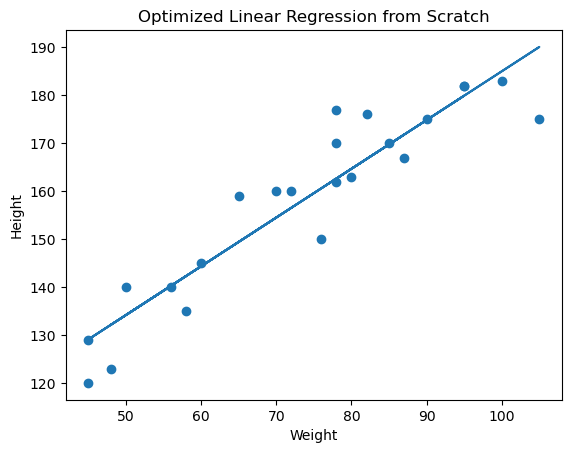

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("./height-weight.csv")

# Extract values
X_original = df["Weight"].values
y = df["Height"].values

# -------- Feature Scaling --------
X_mean = np.mean(X_original)
X_std = np.std(X_original)

X = (X_original - X_mean) / X_std

# -------- Initialize Parameters --------
m = 0
b = 0

learning_rate = 0.0011
iterations = 10000
n = len(X)

# -------- Loss Function --------
def loss_function(m, b, X, y):
    return np.mean((y - (m * X + b)) ** 2)

# -------- Gradient Descent --------
for i in range(iterations):
    y_pred = m * X + b
    
    dm = (-2/n) * np.sum(X * (y - y_pred))
    db = (-2/n) * np.sum(y - y_pred)
    
    m -= learning_rate * dm
    b -= learning_rate * db
    
    if i % 1000 == 0:
        print(f"Iteration {i}, Loss: {loss_function(m, b, X, y)}")

print("\nFinal parameters (scaled space):")
print("m =", m)
print("b =", b)

# -------- Convert Line Back to Original Scale --------
# Because we trained on scaled X, we must convert slope back

m_original = m / X_std
b_original = b - (m * X_mean / X_std)

print("\nFinal equation in original scale:")
print(f"Height = {m_original:.4f} * Weight + {b_original:.4f}")

# -------- Plot --------
plt.scatter(X_original, y)
plt.plot(X_original, m_original * X_original + b_original)
plt.xlabel("Weight")
plt.ylabel("Height")
plt.title("Optimized Linear Regression from Scratch")
plt.show()

Sklearn Results:
Slope (m): 1.0165441631400496
Intercept (b): 83.34382656470417
Mean Squared Error: 48.42298848348489
R2 Score: 0.8670250581004406


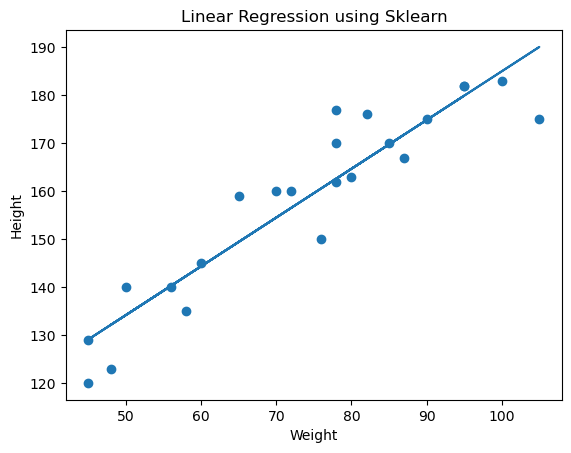

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("./height-weight.csv")

# Features and target
X = df["Weight"].values.reshape(-1, 1)   # sklearn needs 2D input
y = df["Height"].values

# Create model
model = LinearRegression()

# Train model
model.fit(X, y)

# Predictions
y_pred = model.predict(X)

# Parameters
print("Sklearn Results:")
print("Slope (m):", model.coef_[0])
print("Intercept (b):", model.intercept_)

# Metrics
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

# Plot
plt.scatter(X, y)
plt.plot(X, y_pred)
plt.xlabel("Weight")
plt.ylabel("Height")
plt.title("Linear Regression using Sklearn")
plt.show()

Closed Form Solution:
Slope: 1.01654416314005
Intercept: 83.34382656470414

Gradient Descent Solution:
Slope: 1.0165441631400451
Intercept: 83.3438265647038

Mean Squared Error: 48.422988483484886
R² Score: 0.8670250581004407
Final Gradient Magnitude: 1.4120872572126566e-12


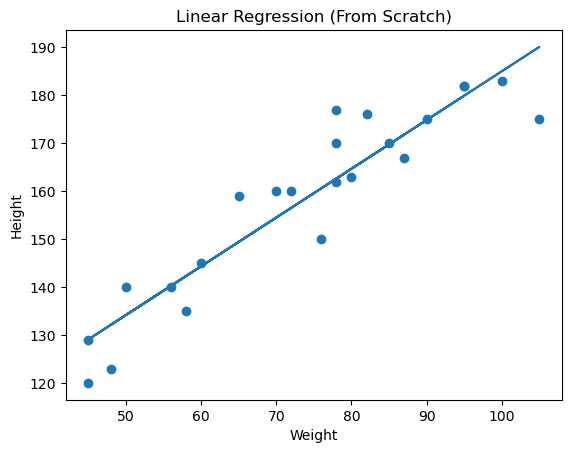

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("./height-weight.csv")

X = df["Weight"].values
y = df["Height"].values

# ------------------------------
# 1️⃣ Closed Form Solution (Normal Equation)
# ------------------------------

X_mean = np.mean(X)
y_mean = np.mean(y)

numerator = np.sum((X - X_mean) * (y - y_mean))
denominator = np.sum((X - X_mean) ** 2)

m_closed = numerator / denominator
b_closed = y_mean - m_closed * X_mean

print("Closed Form Solution:")
print("Slope:", m_closed)
print("Intercept:", b_closed)


# ------------------------------
# 2️⃣ Gradient Descent
# ------------------------------

# Standardize X for stable training
X_scaled = (X - X_mean) / np.std(X)

m = 0
b = 0
learning_rate = 0.01
iterations = 10000
n = len(X_scaled)

for i in range(iterations):
    y_pred = m * X_scaled + b
    
    dm = (-2/n) * np.sum(X_scaled * (y - y_pred))
    db = (-2/n) * np.sum(y - y_pred)
    
    m -= learning_rate * dm
    b -= learning_rate * db

# Convert back to original scale
m_gd = m / np.std(X)
b_gd = b - (m * X_mean / np.std(X))

print("\nGradient Descent Solution:")
print("Slope:", m_gd)
print("Intercept:", b_gd)


# ------------------------------
# 3️⃣ MSE
# ------------------------------

y_pred_gd = m_gd * X + b_gd
mse = np.mean((y - y_pred_gd) ** 2)

print("\nMean Squared Error:", mse)


# ------------------------------
# 4️⃣ R² Score
# ------------------------------

ss_total = np.sum((y - y_mean) ** 2)
ss_residual = np.sum((y - y_pred_gd) ** 2)

r2 = 1 - (ss_residual / ss_total)

print("R² Score:", r2)


# ------------------------------
# 5️⃣ Gradient Magnitude (Convergence Check)
# ------------------------------

gradient_magnitude = np.sqrt(dm**2 + db**2)
print("Final Gradient Magnitude:", gradient_magnitude)


# ------------------------------
# Plot
# ------------------------------

plt.scatter(X, y)
plt.plot(X, y_pred_gd)
plt.xlabel("Weight")
plt.ylabel("Height")
plt.title("Linear Regression (From Scratch)")
plt.show()